# Assignment 2 - Sentiment Analysis (Part 1: RNN, GRU, & LSTM)

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

# Comparative Analysis: Sentiment Analysis Using BERT, LSTM, GRU, and RNN

## **Objective**

Perform sentiment analysis on the given dataset using multiple deep learning models: **BERT**, **LSTM**, **GRU**, and **RNN**, and conduct a comparative analysis based on their performance metrics.

[Dataset](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/data)

---

## **Dataset Implementation Plan**

### 1. **Data Preprocessing**

- **Load the Dataset:**  
  Import the CSV file and extract the relevant columns (`polarity`, `text`).

- **Clean the Text:**  
  Remove URLs, special characters, numbers, and extra spaces. Convert text to lowercase.

- **Tokenization:**  
  Split the text into individual tokens using a tokenizer suitable for each model (e.g., Word2Vec for RNN-based models, BERT tokenizer for BERT).

- **Class Mapping:**  
  - 0 → Negative  
  - 2 → Neutral  
  - 4 → Positive

- **Train-Test Split:**  
  Divide the data into training, validation, and test sets.

---

### 2. **Feature Engineering**

- **BERT Tokenization:**  
  Use a pre-trained BERT tokenizer to convert the text into input IDs, attention masks, and token type IDs.

- **Embedding for RNN-based Models:**  
  - Generate word embeddings using GloVe or Word2Vec.  
  - Pad sequences to a fixed length for uniformity.

---

### 3. **Model Implementation**

- **BERT:**  
  - Use a pre-trained BERT model from the Hugging Face library.  
  - Add a classification head (e.g., a dense layer with softmax activation) to fine-tune the model.

- **LSTM:**  
  - Use a sequential model with embedding, LSTM layers, and a dense output layer.

- **GRU:**  
  - Similar to LSTM but replace LSTM layers with GRU layers for comparison.

- **RNN:**  
  - Use simple RNN layers instead of LSTM/GRU for baseline comparison.

---

### 4. **Evaluation Metrics**

- **Accuracy:**  
  Overall percentage of correct predictions.

- **Precision, Recall, F1-Score:**  
  Evaluate per class (negative, neutral, positive).

- **Confusion Matrix:**  
  Show performance across all classes.

- **ROC-AUC Score:**  
  Measure the ability of the model to distinguish between classes.

---

### 5. **Comparative Analysis**

Compare the models on:

- Performance metrics (accuracy, precision, recall, F1-score).
- Computational requirements (training time, memory usage).
- Complexity of implementation.

Generate visualizations:

- Bar chart comparing F1-scores for all models.
- Line plot showing training/validation loss and accuracy over epochs.
- Confusion matrix heatmaps for each model.

---

### 6. **Expected Outcome**

- **BERT:**  
  Likely to outperform RNN-based models due to its pre-trained contextual embeddings and transformer architecture.

- **LSTM/GRU:**  
  Expected to perform better than simple RNN due to their ability to handle long-term dependencies and avoid vanishing gradient problems.

- **RNN:**  
  May provide a baseline but is likely to underperform compared to other models.

---

### 7. **Deliverables**

- Code implementation for each model in Python (using libraries like TensorFlow, PyTorch, Hugging Face).
- Comparative analysis report with:
  - Metric tables
  - Charts and graphs
  - Insights on model performance
- Recommendations on the best model for deployment based on trade-offs between performance and resource usage.

  </p>
</details>

## Importing Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from gensim.models import Word2Vec
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Loading Datasets

We load the `train.csv` and `test.csv` datasets.

We rename `sentiment` to `polarity` and encode it to `{"negative": 0, "neutral":1, "positive": 2}`.

We drop the unnecessary columns

In [3]:
# read the dataset
train_df = pd.read_csv("../Assignment 1/Data/train.csv", encoding="Windows-1252")
train_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
train_df = train_df[["text", "polarity"]]

# read the dataset
test_df = pd.read_csv("../Assignment 1/Data/test.csv", encoding="Windows-1252")
test_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
test_df = test_df[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

train_df["polarity"] = train_df["polarity"].map(label_map)
test_df["polarity"] = test_df["polarity"].map(label_map)

test_df.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


We drop the rows that contain `NaN` values.

In [4]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
train_df['polarity'] = train_df['polarity'].astype('int') 
print(f"{before - len(train_df)} NaN rows dropped from train.")

before = len(test_df)
test_df.dropna(how="any", inplace=True)
test_df['polarity'] = test_df['polarity'].astype('int') 
print(f"{before - len(test_df)} NaN rows dropped from test.")

1 NaN rows dropped from train.
1281 NaN rows dropped from test.


We create a function named to preprocess the text:

- Remove URLs
- Remove HTML tags
- Remove all non-alphabetic characters
- Apply lowercase
- Tokenize

In [5]:
def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")
    
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Keep only letters and whitespaces
    pattern = r"[a-zA-Z\s']"
    text = ''.join(re.findall(pattern, text))
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    
    return tokens

In [6]:
#apply the text_preprocess to 
train_df["text_preprocessed"] = train_df["text"].apply(text_preprocess)
test_df["text_preprocessed"] = test_df["text"].apply(text_preprocess)

#check the head of train data
train_df.head()

,text,polarity,text_preprocessed
0,"I`d have responded, if I were going",1,"[id, have, responded, if, i, were, going]"
1,Sooo SAD I will miss you here in San Diego!!!,0,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,my boss is bullying me...,0,"[my, boss, is, bullying, me]"
3,what interview! leave me alone,0,"[what, interview, leave, me, alone]"
4,"Sons of ****, why couldn`t they put them on t...",0,"[sons, of, why, couldnt, they, put, them, on, ..."


We do some descriptive statistics on `text_preprocessed` column and we find out that the max is 33 tokens

In [7]:
train_df["text_preprocessed"].apply(lambda x: len(x)).describe()

count    27480.000000
mean        12.564702
std          6.795787
min          0.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: text_preprocessed, dtype: float64

<Axes: xlabel='text_preprocessed', ylabel='Count'>

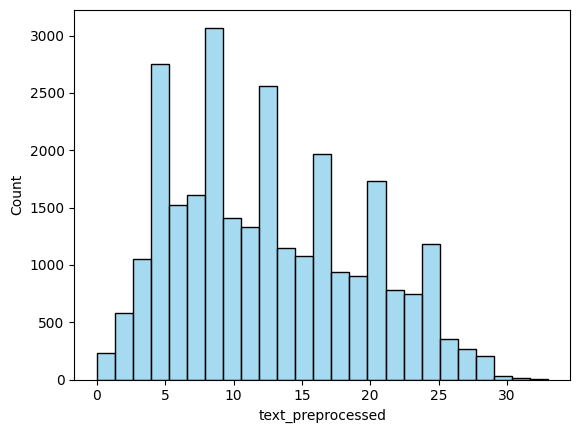

In [8]:
# Calculate word counts
train_word_counts = train_df['text_preprocessed'].apply(lambda x: len(x))

# Create side-by-side histograms with separate y-axis scales
sns.histplot(x=train_word_counts, bins=25, color='skyblue')

The dataset has no duplicated to drop.

We visualize the labels distribution.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

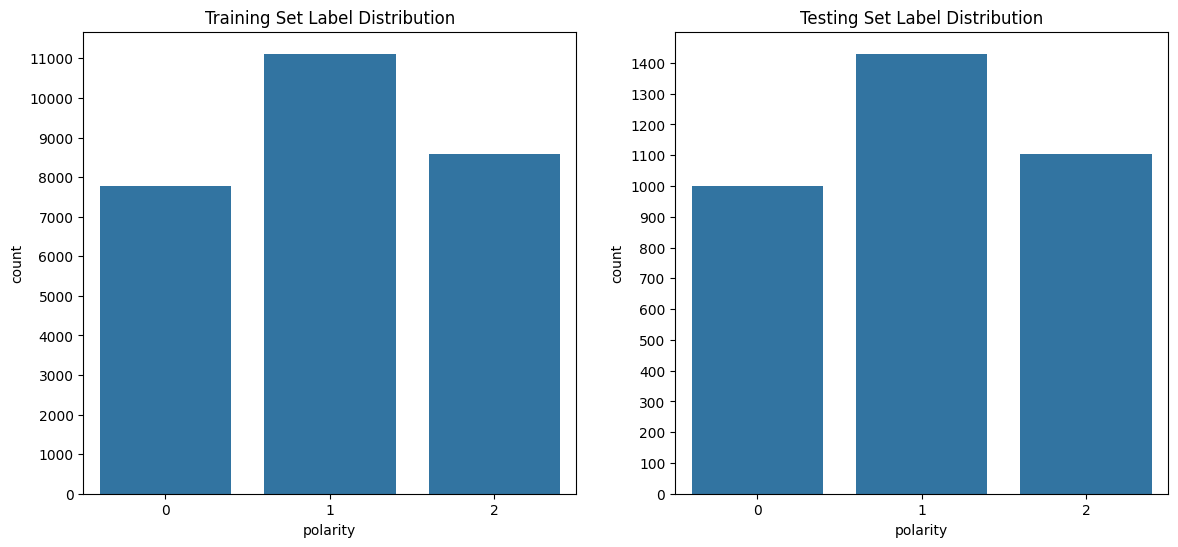

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set plot
sns.countplot(data=train_df, x="polarity", ax=axes[0])
axes[0].set_title("Training Set Label Distribution")
axes[0].set_yticks(np.arange(0, 12000, 1000))

# Testing set plot
sns.countplot(data=test_df, x="polarity", ax=axes[1])
axes[1].set_title("Testing Set Label Distribution")
axes[1].set_yticks(np.arange(0, 1500, 100))

# Adjust layout
plt.tight_layout


The dataset are well balanced, with a neutral sentiment being slightly above the other sentiments.

Next, we embed the tokens using word2vec embeddings.

In [9]:
# Fetch embeddings
word2vec_model = Word2Vec(
    sentences=train_df.text_preprocessed.values.tolist(), 
    vector_size=128, min_count=1, workers=4
    )

# Get vocabulary size
vocab_size = len(word2vec_model.wv)
print(vocab_size)

27051


In [10]:
# Helper functions

# Convert text to Word2Vec embeddings

def text_to_embeddings(text, word2vec_model, seq_length):
    embeddings = []
    vector_size = word2vec_model.vector_size
    wv = word2vec_model.wv # Use 'wv' for clarity

    for i, word in enumerate(text):
        if i >= seq_length:
            break
        if word in wv:
            embeddings.append(wv[word])
        # else: word not in vocab, skipped

    # Convert the list of embeddings to a 2D NumPy array *first*
    # We specify the dtype and ensure it's 2D even if empty or partial
    embeddings_np = np.array(embeddings, dtype=np.float32).reshape(-1, vector_size)

    # Padding logic
    if len(embeddings_np) < seq_length:
        padding_needed = seq_length - len(embeddings_np)
        # Create a single numpy array for padding zeros
        zero_padding = np.zeros((padding_needed, vector_size), dtype=np.float32)
        
        # Concatenate using numpy (both are now guaranteed 2D arrays)
        embeddings_np = np.concatenate((zero_padding, embeddings_np), axis=0)
    else:
        # If no padding needed, ensure we return exactly seq_length items
        embeddings_np = embeddings_np[:seq_length]

    # Ensure the final output is a single numpy array of the correct shape
    # The final shape will be (seq_length, vector_size) e.g., (64, 300)
    return embeddings_np

# Prepare data
def prepare_data(reviews, labels, word2vec_model, seq_length):
    # Step 1: Process all reviews into a list of individual NumPy arrays
    # This step is unavoidable as you need to process each review sequence individually
    list_of_embedding_arrays = [text_to_embeddings(review, word2vec_model, seq_length) for review in reviews]

    # Step 2: Convert the list of NumPy arrays into a *single* large NumPy array
    # This is the key optimization step recommended by PyTorch
    X_np = np.array(list_of_embedding_arrays, dtype=np.float32)

    # Step 3: Convert the single, large NumPy array into a single PyTorch tensor
    # This is much faster than creating tensors in a loop
    X = torch.tensor(X_np, dtype=torch.float32)
    
    # Step 4: Convert labels to a single tensor (already efficient)
    y = torch.tensor(labels, dtype=torch.long)
    
    return X, y

## BiRNN

In [ ]:
class SentimentBiRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5):
        super(SentimentBiRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Using RNN for the recurrent layer
        self.bi_rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True,
                             bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)

        # Doubling the output size because of bidirectionality
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # Initialize hidden state for RNN
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the RNN
        out, _ = self.bi_rnn(x, h0)
        # Get the last time step's output for the fully connected layer
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Define hyperparameters
input_size = word2vec_model.vector_size
hidden_size = 128
output_size = 3
num_layers = 1
learning_rate = 0.001
dropout_rate = 0.5

In [13]:
# Initialize model, loss function, and optimizer
model = SentimentBiRNN(input_size, hidden_size, output_size, num_layers, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [14]:
# Training Params
num_epochs = 30  # Number of epochs
max_patience = 5  # Maximum epochs to wait for improvement
batch_size = 16
seq_length = 32

In [15]:
# Prepare data
X_train, y_train = prepare_data(train_df.text_preprocessed, train_df.polarity,
                                word2vec_model, seq_length)

X_val, y_val = prepare_data(test_df.text_preprocessed, test_df.polarity,
                            word2vec_model, seq_length)

In [16]:
# Create DataLoader
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [17]:
# Create DataLoader
val_data = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

In [18]:
#Training loop

losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1:02d}/{num_epochs}, Train Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bidirectional_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 01/30, Train Loss: 1.0442, Val Loss: 1.0484
Epoch 02/30, Train Loss: 1.0369, Val Loss: 1.0267
Epoch 03/30, Train Loss: 1.0225, Val Loss: 1.0200
Epoch 04/30, Train Loss: 1.0207, Val Loss: 0.9911
Epoch 05/30, Train Loss: 0.9962, Val Loss: 0.9937
Epoch 06/30, Train Loss: 1.0216, Val Loss: 1.0514
Epoch 07/30, Train Loss: 1.0341, Val Loss: 1.0109
Epoch 08/30, Train Loss: 1.0164, Val Loss: 1.0649
Epoch 09/30, Train Loss: 1.0309, Val Loss: 1.0210
Early stopped at 9
Lowest Validation Loss: 0.9911 at Epoch 4


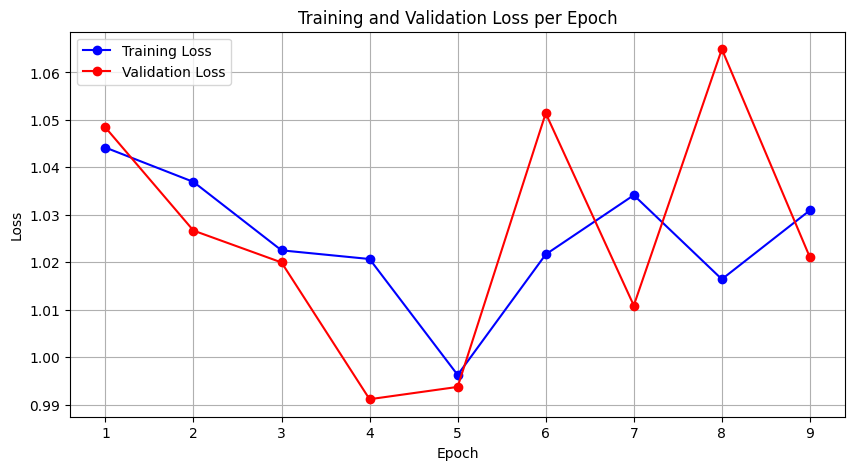

In [19]:
# Plotting the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [20]:
# Define all functions required for evaluation

def compute_metrics_from_preds(labels, preds):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

def compute_outputs(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_proba = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device).float()
            all_labels.extend(labels)
            outputs = model(inputs)
            all_preds.extend(outputs.argmax(dim=1))
            all_proba.extend(F.softmax(outputs, dim=1))
    
    return all_labels, all_preds, all_proba

def plot_conf_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    labels = ["negative", "neutral", "positive"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

def plot_roc_auc(all_labels, all_proba):
    # Convert lists to numpy arrays
    all_labels = np.array(all_labels)
    all_proba = np.array(all_proba)

    # Define the labels
    labels = ["negative", "neutral", "positive"]
    n_classes = len(labels)

    # Binarize the true labels for the one-vs-rest strategy
    y_true_bin = label_binarize(all_labels, classes=range(n_classes))

    if not isinstance(y_true_bin, np.ndarray):
        y_true_bin = np.array(y_true_bin)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        # This slicing now works because y_true_bin and all_proba are numpy arrays
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plotting the ROC curves
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red'] # Customize colors as needed

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                label='ROC curve of class {0} (area = {1:0.2f})'.format(labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (area = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
    plt.legend(loc="lower right")

    # Calculate macro-averaged ROC AUC score (overall metric)
    macro_roc_auc_ovr = roc_auc_score(all_labels, all_proba, multi_class="ovr", average="macro")
    print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr:.2f}")

In [21]:
# Load the best model
model.load_state_dict(torch.load('bidirectional_best_model.pth'))

all_labels, all_preds, all_proba = compute_outputs(model, val_loader)

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.5076400679117148,
 'precision': 0.5190358413815813,
 'recall': 0.5076400679117148,
 'f1': 0.4916136293290624}

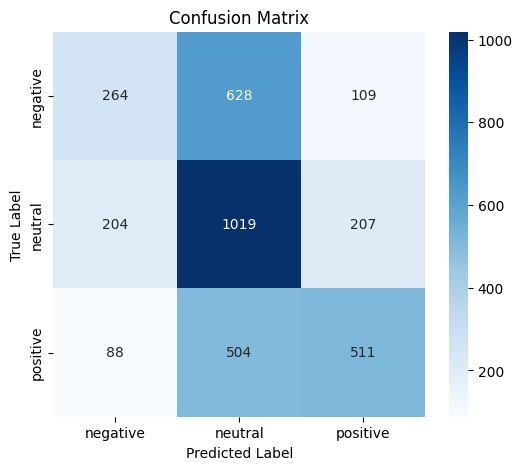

In [22]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.68


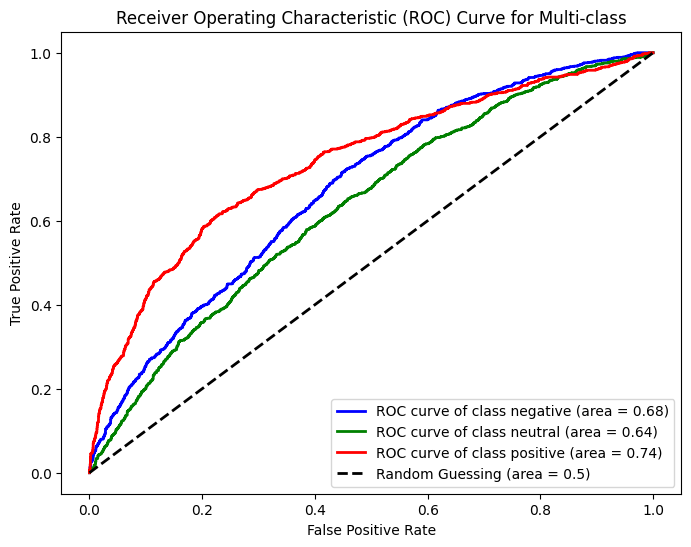

In [23]:
plot_roc_auc(all_labels, all_proba)

## Using Bi-Directional GRU Model

In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, 
                          bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)  # Output size is doubled because of bidirectionality
    
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the GRU
        out, _ = self.gru(x, h0)
        # Apply dropout
        out = self.dropout(out)
        # Use only the last output for the fully connected layer
        out = self.fc(out[:, -1, :])

        return out

In [ ]:
# Initialize model, loss function, and optimizer
model = SentimentGRU(input_size, hidden_size, output_size, num_layers, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [26]:
#Training loop

losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1:02d}/{num_epochs}, Train Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_gru_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 01/30, Train Loss: 0.9498, Val Loss: 0.8807
Epoch 02/30, Train Loss: 0.8770, Val Loss: 0.8460
Epoch 03/30, Train Loss: 0.8495, Val Loss: 0.8253
Epoch 04/30, Train Loss: 0.8275, Val Loss: 0.8077
Epoch 05/30, Train Loss: 0.8101, Val Loss: 0.7930
Epoch 06/30, Train Loss: 0.7958, Val Loss: 0.7855
Epoch 07/30, Train Loss: 0.7835, Val Loss: 0.7956
Epoch 08/30, Train Loss: 0.7694, Val Loss: 0.7768
Epoch 09/30, Train Loss: 0.7557, Val Loss: 0.7840
Epoch 10/30, Train Loss: 0.7438, Val Loss: 0.7998
Epoch 11/30, Train Loss: 0.7272, Val Loss: 0.7704
Epoch 12/30, Train Loss: 0.7163, Val Loss: 0.7786
Epoch 13/30, Train Loss: 0.6965, Val Loss: 0.7718
Epoch 14/30, Train Loss: 0.6856, Val Loss: 0.7824
Epoch 15/30, Train Loss: 0.6669, Val Loss: 0.8300
Epoch 16/30, Train Loss: 0.6518, Val Loss: 0.8034
Early stopped at 16
Lowest Validation Loss: 0.7704 at Epoch 11


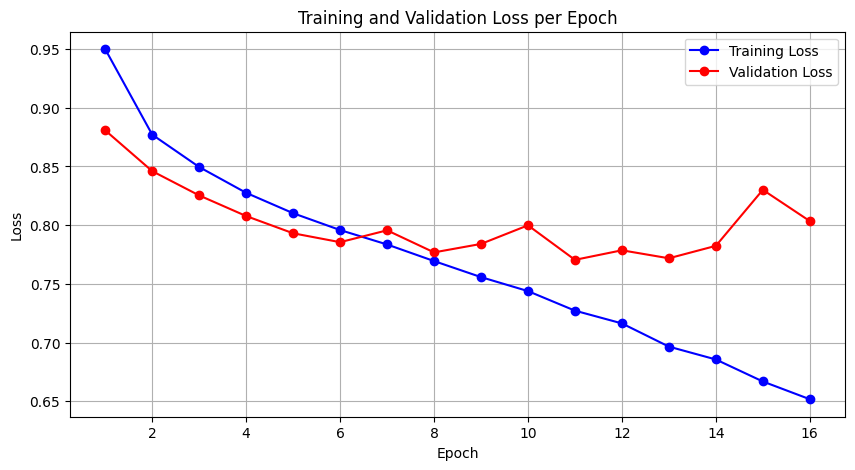

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [28]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_gru_best_model.pth'))

all_labels, all_preds, all_proba = compute_outputs(model, val_loader)

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.6615732880588568,
 'precision': 0.6693709725718221,
 'recall': 0.6615732880588568,
 'f1': 0.6612599093752146}

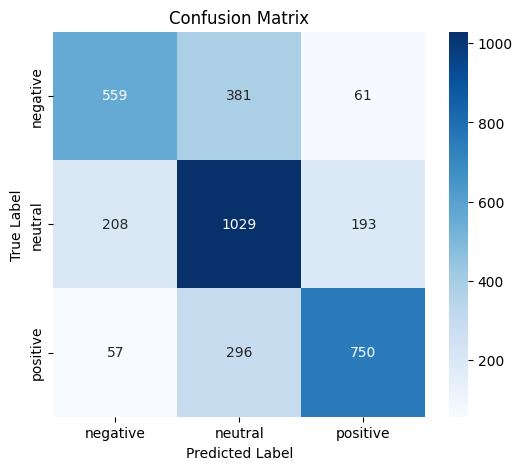

In [29]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.83


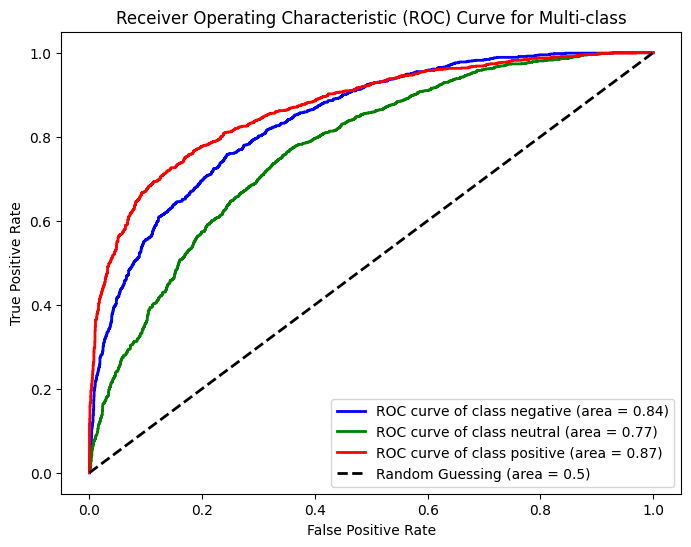

In [30]:
plot_roc_auc(all_labels, all_proba)

## Bidirectional LSTM Model

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5):
        super(SentimentLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Create LSTM layers with nn.LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        
        # Define dropout layer
        self.dropout = nn.Dropout(dropout_rate)

        # Fully connected layer (output size is doubled for bidirectionality)
        self.fc = nn.Linear(hidden_size * 2, output_size)


    def forward(self, x):
        h_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)

        outputs, _ = self.lstm(x, (h_0, c_0))
        
        # Apply dropout and fully connected layer
        outputs = self.dropout(outputs)
        
        out = self.fc(outputs[:, -1, :])

        return out


In [ ]:
# Initialize model, loss function, and optimizer
model = SentimentLSTM(input_size, hidden_size, output_size, num_layers, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [33]:
#Training loop

losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1:02d}/{num_epochs}, Train Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_lstm_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 01/30, Train Loss: 0.9666, Val Loss: 0.9008
Epoch 02/30, Train Loss: 0.8888, Val Loss: 0.8581
Epoch 03/30, Train Loss: 0.8567, Val Loss: 0.8374
Epoch 04/30, Train Loss: 0.8388, Val Loss: 0.8184
Epoch 05/30, Train Loss: 0.8228, Val Loss: 0.8033
Epoch 06/30, Train Loss: 0.8075, Val Loss: 0.8032
Epoch 07/30, Train Loss: 0.7972, Val Loss: 0.7867
Epoch 08/30, Train Loss: 0.7862, Val Loss: 0.7807
Epoch 09/30, Train Loss: 0.7761, Val Loss: 0.7831
Epoch 10/30, Train Loss: 0.7624, Val Loss: 0.7829
Epoch 11/30, Train Loss: 0.7502, Val Loss: 0.7857
Epoch 12/30, Train Loss: 0.7404, Val Loss: 0.7758
Epoch 13/30, Train Loss: 0.7297, Val Loss: 0.7721
Epoch 14/30, Train Loss: 0.7131, Val Loss: 0.7820
Epoch 15/30, Train Loss: 0.7009, Val Loss: 0.7704
Epoch 16/30, Train Loss: 0.6865, Val Loss: 0.7795
Epoch 17/30, Train Loss: 0.6716, Val Loss: 0.7808
Epoch 18/30, Train Loss: 0.6531, Val Loss: 0.8035
Epoch 19/30, Train Loss: 0.6343, Val Loss: 0.8175
Epoch 20/30, Train Loss: 0.6180, Val Loss: 0.8412


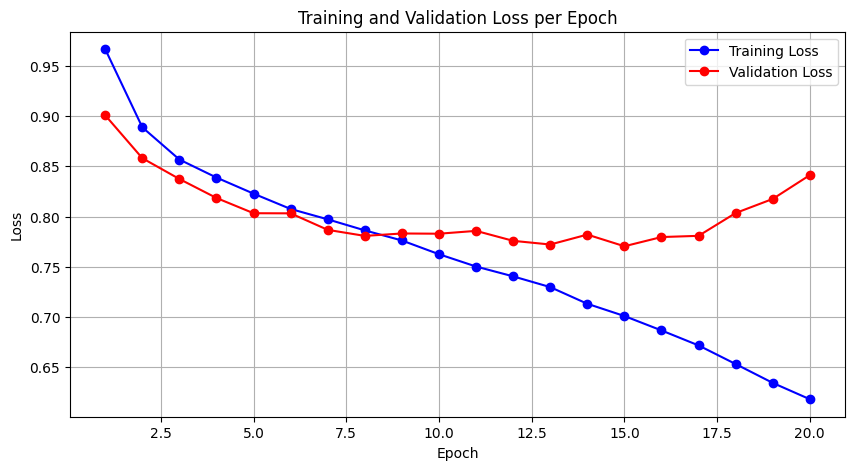

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [35]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_lstm_best_model.pth'))

all_labels, all_preds, all_proba = compute_outputs(model, val_loader)

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.6502546689303905,
 'precision': 0.673776390204479,
 'recall': 0.6502546689303905,
 'f1': 0.6504751504826507}

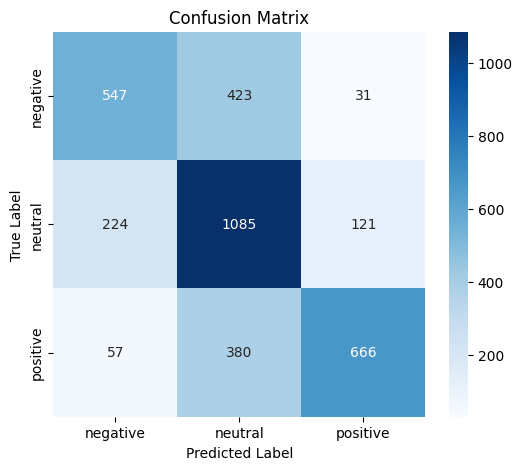

In [36]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.83


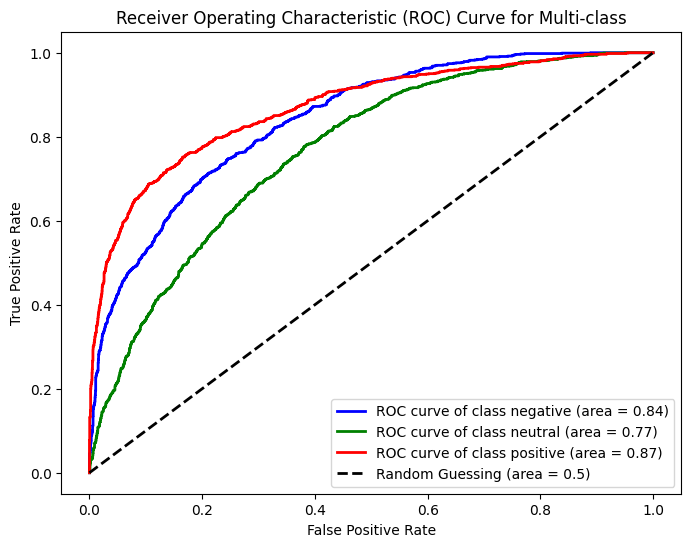

In [37]:
plot_roc_auc(all_labels, all_proba)

## Comparative Study & Conclusion

Cf. Part 2: `Assignment_02_BERT.ipynb`